**Enable DRIVE**

In [1]:
try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)

    print("Google Drive is mounted correctly")

except ModuleNotFoundError:

    print("Local environment detected (not Colab)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive is mounted correctly


**Read the files**

In [2]:


import os
import pandas as pd
import matplotlib.pyplot as plt

"""
The `ruta_archivos` variable specifies the location of the file,
and `archivos` is a list containing the file names.
For this to work properly, the files must be in `.txt` format and have sequential numbers.
The range is defined based on the number of files you have:
For example, if you have name1.txt ... name10.txt, then the range would be
range(1,11) because it starts at 1 and ends at 10, since the 11th file is not read.

"""

ruta_archivos = "/content/drive/MyDrive/Doctorado/Proyecto_ICF/reduccion colorante con aunps papalo 24 01 2025-20260513T215036Z-3-001/"



def extraer_datos(nombre_archivo):
    with open(nombre_archivo, 'r', encoding='latin1') as f:
        lineas = f.readlines()

    inicio = None
    for i, linea in enumerate(lineas):
        if "Data Points" in linea:
            inicio = i + 2
            break
    if inicio is None:
        raise ValueError(f"No ‘Data Points’ were found in {nombre_archivo}")

    df = pd.read_csv(
        nombre_archivo,
        sep="\t",
        skiprows=inicio,
        names=["nm", "Abs"],
        encoding='latin1'
    )

    df = df.dropna()
    df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
    df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")
    df = df.dropna()

    return df

archivos = [f"REDU COL. Ver +  H2O + NaBH4 + AuNPs PAPALO  {i}.TXT" for i in range(1,5)]
archivos = [ruta_archivos + f for f in archivos]

# Verificar existencia
for a in archivos:
    if not os.path.exists(a):
        print(f"⚠️ File not found: {a}")
    else:
        extraer_datos(a).to_csv(
            ruta_archivos + os.path.splitext(os.path.basename(a))[0] + "_limpio.txt",
            sep="\t",
            index=False
        )

**PLOT**

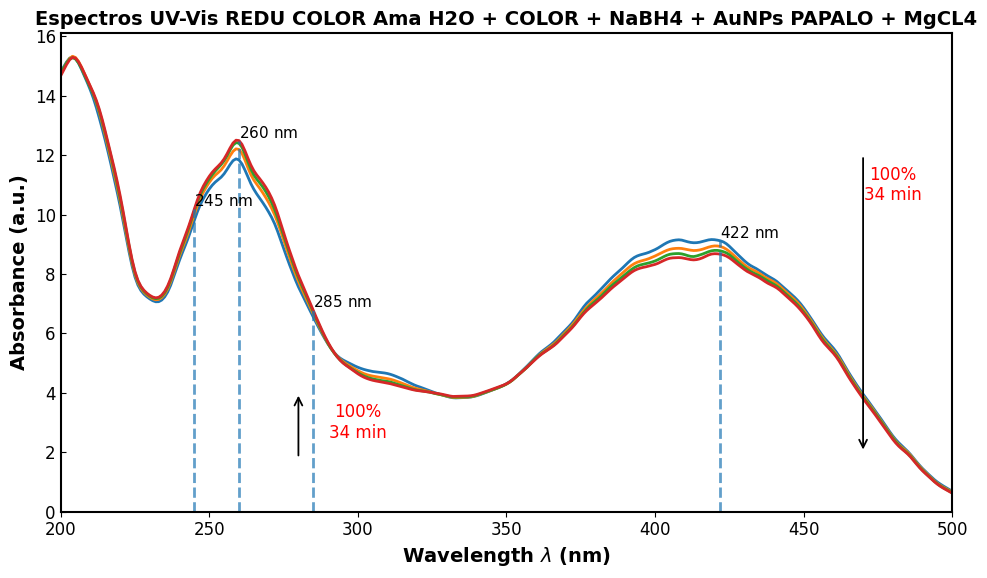


 TABLE 1 (Abs a 410 nm):
   X   Abs_410
0  0  9.115714
1  2  8.844143
2  4  8.653274
3  6  8.528641


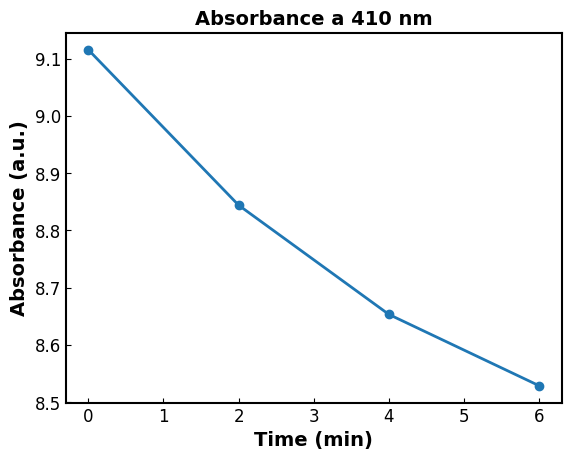


 TABLE 2 (Normalize):
   X  Abs_norm
0  0  1.000000
1  2  0.970208
2  4  0.949270
3  6  0.935598


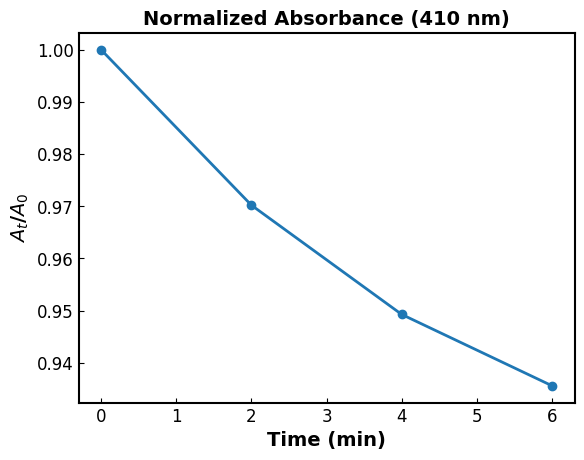


TABLE 3 (Log):
   X  ln(Abs_norm)
0  0      0.000000
1  2     -0.030244
2  4     -0.052062
3  6     -0.066570


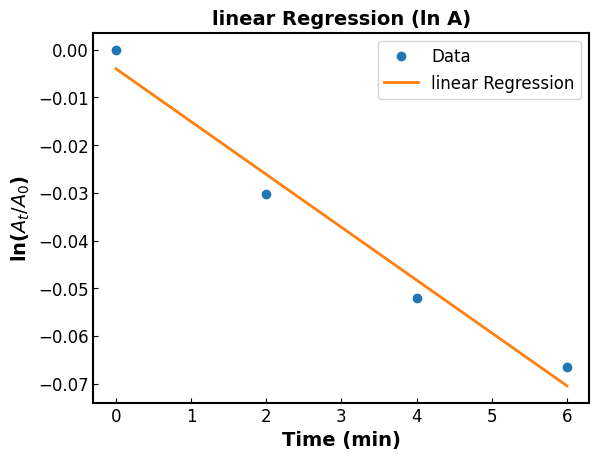

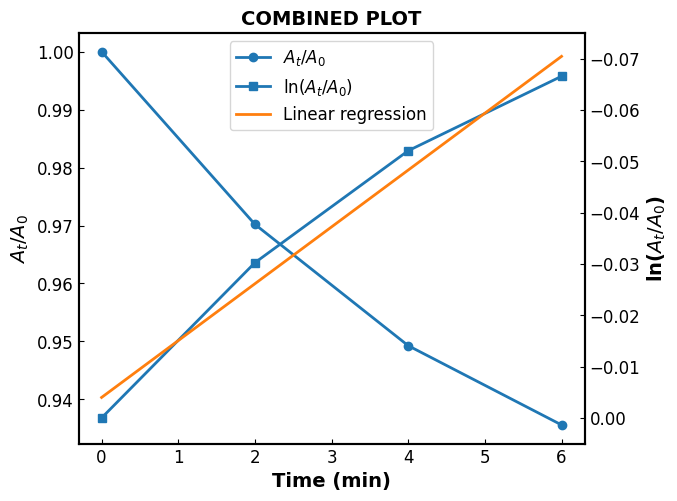


slope: -0.011076
Standard error slope: 0.001245

IC 95% slope:
[-0.016432, -0.005721]

Intercept: -0.003990
Standard error intercept: 0.004657

R²: 0.9754

Constant speed k: 0.011076

IC 95% to k:
[0.005721, 0.016432]

 Efficiency to 410 nm: 6.44%

 k′ = k/m = 11245.015288 (unidades dependen de k y m)
 Qt = 387.408645 g/g

ΔG‡ = 94.3311 kJ/mol
Standard error ΔG‡ = ±0.2786 kJ/mol

IC 95% ΔG‡:
[93.1326, 95.5297] kJ/mol

 TON y TOF
Mass of the pollutant after degradation = 0.000042 g
Moles of degraded pollutant = 6.308481e-08 mol
Moles of catalyst = 5.000762e-09 mol

 TON = 12.615042
 TOF = 2.102507 min^-1


In [6]:
plt.figure(figsize=(10, 6))

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.5,
    "lines.linewidth": 2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# =====================================================
# EXPERIMENTAL DATA (ADJUST ACCORDING TO YOUR EXPERIMENT)
# =====================================================

m = 0.000000985   # catalyst mass (g)
M = 0.00065    # mass of the organic contaminant (g)

masa_molar_catalizador = 196.97   # g/mol (example: Ag = 107.87, Au = 196.97)
masa_molar_contaminante = 663.575  # g/mol (example: 4-NF ≈ 139.11 g/mol)

T = 298.15  # temperature en K

# Physical constants
kb = 1.380649e-23   # Boltzmann's constant (J/K)
h = 6.62607015e-34  # Planck's constant (J·s)
R = 8.314           # Gas constant (J/mol·K)

####### Data for the graphs #################################

#######  lines in the UV-VIS spectrum ##############################
valores_primera = [ 422 ]   # relative to the first curve
valores_ultima = [245, 260, 285]    # relative to the last curve

####### wavelength (nm) at which the statistical analysis will be performed########

lambda_objetivo = 410   # CHANGE THE WAVELENGTH (nm) HERE

##############################################################################
### UV-VIS spectrum
##############################################################################

y_primera = {}
y_ultima = {}

for i, archivo in enumerate(archivos):
    df = extraer_datos(archivo)

    plt.plot(
        df["nm"],
        df["Abs"],
        label=rf"$\mathrm{{Lluvia\ 4NF}}_{{{i+1}}}$"
   )


    if i == 0:
        for x_nm in valores_primera:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_primera[x_nm] = y_nm


    if i == len(archivos) - 1:
        for x_nm in valores_ultima:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_ultima[x_nm] = y_nm



for x_nm, y_nm in y_primera.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

for x_nm, y_nm in y_ultima.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

########################################################################
## LINES AND ARROWS
########################################################################
# Vertical lines
#plt.plot([200, 250], [0, 15], linestyle='dashed' , alpha=0.7)

# Down arrow
plt.annotate(
    '',
    xy=(470, 2),      # full stop (below)
    xytext=(470, 12),  # starting point (top)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# label above the arrow
plt.text(480, 11, "100%\n34 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

# Up arrow
plt.annotate(
    '',
    xy=(280, 4),      # full stop (below)
    xytext=(280, 1.8),  # starting point (top)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# label above the arrow
plt.text(300, 3, "100%\n34 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

########################################################################

#plt.grid(alpha=0.3)
#plt.legend()## This is for the labels on each line
plt.xlabel(r'Wavelength $\lambda$ (nm)', fontsize=14)
plt.ylabel(r'Absorbance (a.u.)', fontsize=14)
plt.title(r'Espectros UV-Vis REDU COLOR Ama H2O + COLOR + NaBH4 + AuNPs PAPALO + MgCL4', fontsize=14)


# Axis limits
plt.xlim(200, 500)
plt.ylim(0, None)

#ymin, ymax = plt.ylim()
#xmin, xmax = plt.xlim()

#plt.xticks(np.arange(200, 501, 50))
#plt.yticks(np.arange(0, ymax + 1, 2))

plt.tick_params(axis='x', direction='out')


plt.tight_layout()
plt.savefig(ruta_archivos + "uv_vis.pdf", dpi=600, bbox_inches='tight')
plt.savefig(ruta_archivos + "uv_vis.tif", dpi=600, bbox_inches='tight')
plt.show()



##########################################################################
# Data analysis
##########################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. EXTRACT Abs at variable λ
# =========================

abs_lambda = []

for archivo in archivos:
    df = extraer_datos(archivo)

    fila = df.iloc[(df["nm"] - lambda_objetivo).abs().argsort()[:1]]
    abs_lambda.append(fila["Abs"].values[0])

x = np.arange(0, 2 * len(abs_lambda), 2)

tabla1 = pd.DataFrame({
    "X": x,
    f"Abs_{lambda_objetivo}": abs_lambda
})

print(f"\n TABLE 1 (Abs a {lambda_objetivo} nm):")
print(tabla1)

plt.figure()
plt.plot(x, abs_lambda, marker='o')
plt.title(f"Absorbance a {lambda_objetivo} nm")
plt.xlabel(r'Time (min)', fontsize=14)
plt.ylabel(r'Absorbance (a.u.)')
#plt.grid()
plt.savefig(ruta_archivos + "abs.pdf", dpi=600, bbox_inches='tight')
plt.savefig(ruta_archivos + "abs.tif", dpi=600, bbox_inches='tight')
plt.show()

# =========================
# 2. NORMALIZE
# =========================

abs0 = abs_lambda[0]
abs_norm = [a / abs0 for a in abs_lambda]

tabla2 = pd.DataFrame({
    "X": x,
    "Abs_norm": abs_norm
})

print("\n TABLE 2 (Normalize):")
print(tabla2)

plt.figure()
plt.plot(x, abs_norm, marker='o')
plt.title(f"Normalized Absorbance ({lambda_objetivo} nm)")
plt.xlabel(r'Time (min)')
plt.ylabel(r"$A_t$/$A_0$")
#plt.grid()
plt.savefig(ruta_archivos + "normalizada.pdf", dpi=600, bbox_inches='tight')
plt.savefig(ruta_archivos + "normalizada.tif", dpi=600, bbox_inches='tight')
plt.show()




from scipy.stats import linregress, t

# =========================
# 3. LOG + LINEAR REGRESSION
# =========================

# For pseudo-first-order kinetics:
# ln(Ct/C0) = -kt
# Where:
# Ct is the concentration over time
# C0 is the initial concentration
# K is the reaction rate

log_abs = np.log(abs_norm)

# =========================
# LINEAR REGRESSION
# =========================

resultado = linregress(x, log_abs)

pendiente = resultado.slope
intercepto = resultado.intercept
r_value = resultado.rvalue
stderr_pendiente = resultado.stderr
stderr_intercepto = resultado.intercept_stderr

k = -pendiente

y_fit = pendiente * x + intercepto

r2 = r_value**2

# =========================
# CONFIDENCE INTERVAL 95%
# =========================

n = len(x)
alpha = 0.05

t_crit = t.ppf(1 - alpha/2, df=n-2)

ic_pendiente = (
    pendiente - t_crit * stderr_pendiente,
    pendiente + t_crit * stderr_pendiente
)

ic_intercepto = (
    intercepto - t_crit * stderr_intercepto,
    intercepto + t_crit * stderr_intercepto
)

ic_k = (
    -ic_pendiente[1],
    -ic_pendiente[0]
)

# =========================
# TABLE
# =========================

tabla3 = pd.DataFrame({
    "X": x,
    "ln(Abs_norm)": log_abs
})

print("\nTABLE 3 (Log):")
print(tabla3)

# =========================
# PLOT
# =========================

plt.figure()

plt.plot(x, log_abs, 'o', label="Data")
plt.plot(x, y_fit, '-', label="linear Regression")

plt.title("linear Regression (ln A)")
plt.xlabel(r'Time (min)')
plt.ylabel(r"ln($A_t/A_0$)")

plt.legend()
# plt.grid()
plt.savefig(ruta_archivos + "regrecion.pdf", dpi=600, bbox_inches='tight')
plt.savefig(ruta_archivos + "regrecion.tif", dpi=600, bbox_inches='tight')
plt.show()

# =========================
# COMBINED PLOT
# =========================

fig, ax1 = plt.subplots(figsize=(7,5))

# ---------------------------------
# LEFT AXIS Y
# NORMALIZE
# ---------------------------------

ax1.plot(x,abs_norm,'o-',label=r"$A_t/A_0$")

ax1.set_xlabel(r"Time (min)")

ax1.set_ylabel(r"$A_t/A_0$")

# MANUAL RANGE X
#ax1.set_xlim(0, 60)

# MANUAL Y LEFT RANGE
#ax1.set_ylim(0, 1.2)

# ---------------------------------
# RIGHT Y AXIS
# LOG + REGRESSION
# ---------------------------------

ax2 = ax1.twinx()

ax2.plot(x,log_abs,'s-',label=r"ln($A_t/A_0$)")

ax2.plot(x,y_fit,'-',label="Linear regression")

ax2.set_ylabel(r"ln($A_t/A_0$)")

# MANUAL Y RIGHT RANGE
ax2.set_ylim(0.005 , -0.075)

# ---------------------------------
# COMBINED lABELS
# ---------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,loc='upper center')

# ---------------------------------
# SAVE
# ---------------------------------

plt.tight_layout()

plt.savefig(ruta_archivos + "normalizacion_regresion_combinada.pdf",
            dpi=600,bbox_inches='tight')

plt.savefig(ruta_archivos + "normalizacion_regresion_combinada.tif",
            dpi=600,bbox_inches='tight')
plt.title('COMBINED PLOT')
plt.show()


# =========================
# RESULTS
# =========================

print(f"\nslope: {pendiente:.6f}")
print(f"Standard error slope: {stderr_pendiente:.6f}")

print(f"\nIC 95% slope:")
print(f"[{ic_pendiente[0]:.6f}, {ic_pendiente[1]:.6f}]")

print(f"\nIntercept: {intercepto:.6f}")
print(f"Standard error intercept: {stderr_intercepto:.6f}")

print(f"\nR²: {r2:.4f}")

print(f"\nConstant speed k: {k:.6f}")

print(f"\nIC 95% to k:")
print(f"[{ic_k[0]:.6f}, {ic_k[1]:.6f}]")

# =========================
# 4. EFFICIENCY
# =========================

#Efficiency = C0 - Cf / C0 * 100
# Where:
# Cf is the final concentration
# C0 is the initial concentration

abs_final = abs_lambda[-1]

eficiencia = ((abs0 - abs_final) / abs0) * 100

print(f"\n Efficiency to {lambda_objetivo} nm: {eficiencia:.2f}%")


# =========================
# 5. Activity parameter (k ′)
# =========================

#activity parameter
# k′ = k / m
# Where:
# m is the mass of the catalyst
# k is the reaction rate

k_prima = k / m

print(f"\n k′ = k/m = {k_prima:.6f} (unidades dependen de k y m)")

# =========================
# 6. Reduction capacity (Qt)
# =========================

# Qt = (C0 - Cf) × M / m
# Where:
# m is the mass of the catalyst
# M is the mass of the pollutant
# Cf is the final concentration
# C0 is the initial concentration

Qt = (abs0 - abs_final) * M / m

print(f" Qt = {Qt:.6f} g/g")

# =========================
# 7. ΔG‡ (Free activation energy)
# =========================

#    Eyring equation
#    ΔG‡ = RT ln(kB*T / h*k)
# Where:
# T is the temperature in K
# R is the gas constant
# Kb is Boltzmann's constant
# K is the reaction rate
# h is Planck's constant



# Convert k de min^-1 a s^-1
k_seg = k / 60

# Standard error of k
stderr_k = stderr_pendiente / 60

# =========================
# ΔG‡
# =========================

delta_G = R * T * np.log((kb * T) / (h * k_seg))

# convert a kJ/mol
delta_G_kJ = delta_G / 1000

# =========================
# STANDARD ERROR
# =========================

error_delta_G = (R * T * (stderr_k / k_seg)) / 1000

# =========================
# CONFIDENCE INTERVAL 95%
# =========================

ic_delta_G = (
    delta_G_kJ - t_crit * error_delta_G,
    delta_G_kJ + t_crit * error_delta_G
)

# =========================
# RESULTS
# =========================

print(f"\nΔG‡ = {delta_G_kJ:.4f} kJ/mol")

print(f"Standard error ΔG‡ = ±{error_delta_G:.4f} kJ/mol")

print("\nIC 95% ΔG‡:")
print(f"[{ic_delta_G[0]:.4f}, {ic_delta_G[1]:.4f}] kJ/mol")

# =========================
# 8. Replacement number (TON)
# and Replacement frequency (TOF)
# =========================

# TON = moles_of_contaminant / moles_of_catalyst
# TOF = TON / reaction_time

tiempo_reaccion_min = x[-1]

fraccion_degradada = eficiencia / 100

# =========================
# CALCULATIONS
# =========================


masa_contaminante_degradada = M * fraccion_degradada

moles_contaminante = (
    masa_contaminante_degradada / masa_molar_contaminante
)


moles_catalizador = m / masa_molar_catalizador


TON = moles_contaminante / moles_catalizador


TOF = TON / tiempo_reaccion_min

# =========================
# CALCULATIONS
# =========================

print("\n=========================")
print(" TON y TOF")
print("=========================")

print(f"Mass of the pollutant after degradation = {masa_contaminante_degradada:.6f} g")
print(f"Moles of degraded pollutant = {moles_contaminante:.6e} mol")
print(f"Moles of catalyst = {moles_catalizador:.6e} mol")

print(f"\n TON = {TON:.6f}")
print(f" TOF = {TOF:.6f} min^-1")




TABLE OF RESIDUES:
   Time  Experimental value  Adjusted value   Residue
0     0            0.000000       -0.003990  0.003990
1     2           -0.030244       -0.026143 -0.004102
2     4           -0.052062       -0.048295 -0.003767
3     6           -0.066570       -0.070448  0.003878


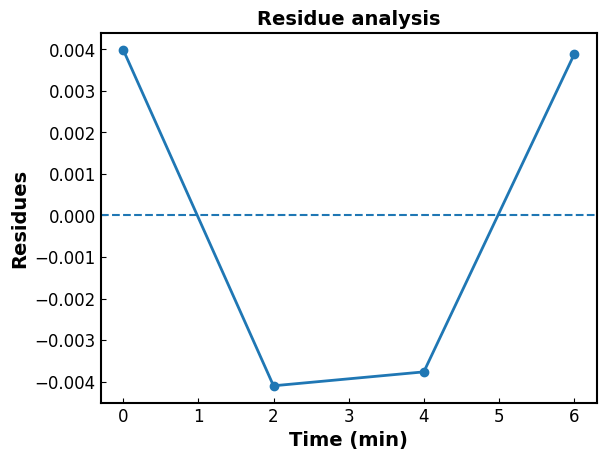

In [7]:
# =========================
# VALIDATION USING
# REGRESSION RESIDUES
# =========================

# Residue:
# ri = yi - ŷi
#
# Where:
# ri  = residual for point i
# yi  = experimental value
# ŷi  = value calculated by the line
#
# If:
# ri > 0  → the point lies above the line
# ri < 0  → the point lies below the line


residuos = log_abs - y_fit

tabla_residuos = pd.DataFrame({
    "Time": x,
    "Experimental value": log_abs,
    "Adjusted value": y_fit,
    "Residue": residuos
})

print("\nTABLE OF RESIDUES:")
print(tabla_residuos)

# =========================
# RESIDUES PLOT
# =========================

plt.figure()

# Horizontal line at zero
plt.axhline(0,
            linestyle='--',
            linewidth=1.5)

# Residues
plt.plot(x,
         residuos,
         'o-')

plt.xlabel(r'Time (min)')
plt.ylabel(r'Residues')

plt.title('Residue analysis')

#plt.grid()
plt.savefig(ruta_archivos + "residuos.pdf", dpi=600, bbox_inches='tight')
plt.savefig(ruta_archivos + "residuos.tif", dpi=600, bbox_inches='tight')
plt.show()